# Trực quan hóa dữ liệu – Lab 02
## Khai thác và trực quan hóa dữ liệu World Development Indicators (WDI)
**GVHD:** Võ Nhật Tân  
**Nhóm:** [MSSV_1, MSSV_2, MSSV_3]  
**Ngày:** 25/03/2026
---


In [21]:
# Cài đặt thư viện
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')


In [22]:
# Đường dẫn dataset
import os
DATA_PATH = '/home/nesfan/Desktop/HCMUS/Nam3/HK2/TQH/DataVis-Lab2/Notebook/data/dataset.csv'

## 1. Phân tích cơ bản về dữ liệu

---

### 1.1 Giới thiệu tổng quan về dataset

**World Development Indicators (WDI)** là bộ dữ liệu do Ngân hàng Thế giới (World Bank) cung cấp, bao gồm hơn 1.600 chỉ số về kinh tế, xã hội và môi trường của hơn 200 quốc gia.

Dataset trong bài phân tích này tập trung vào chỉ số:
- **Tỷ lệ nhập học đại học/cao đẳng (% gross)** – `SE.TER.ENRR`

Dữ liệu gồm nhiều quốc gia (ví dụ: Việt Nam, United Kingdom, United States, Thailand, China) theo giai đoạn 2001–2025.

In [23]:
# Đọc dữ liệu
df_raw = pd.read_csv(DATA_PATH, encoding='latin-1')

### 1.2 Cấu trúc dữ liệu

**Bản ghi (rows):** Mỗi dòng tương ứng với một quốc gia cho chỉ số `SE.TER.ENRR` qua các năm.  
**Trường dữ liệu (columns):**
| Trường | Mô tả |
|---|---|
| `Country Name` | Tên quốc gia |
| `Country Code` | Mã quốc gia (ISO 3-letter) |
| `Series Name` | Tên chỉ số |
| `Series Code` | Mã chỉ số |
| `2001 [YR2001] … 2025 [YR2025]` | Giá trị chỉ số theo từng năm |

Ngoài các dòng dữ liệu chính còn có các dòng footer/metadata ở cuối file và sẽ được loại bỏ ở bước làm sạch.

In [24]:
# Xem toàn bộ dữ liệu gốc
df_raw.head(10)


,Country Name,Country Code,Series Name,Series Code,2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],2006 [YR2006],...,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Viet Nam,VNM,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,2.76,2.12,2.25,2.14,2.078,2.046,...,1.848000,1.874000,1.161,1.681000,2.103,2.383000,1.570000,1.645,1.602,1.523
1,Viet Nam,VNM,"School enrollment, tertiary (% gross)",SE.TER.ENRR,9.30103015899658,9.55722999572754,9.91792964935303,..,15.8760204315185,16.8052501678467,...,29.081198,25.952631,..,30.224119,..,41.955497,44.753685,32.8415128147815,37.5923642016718,..
2,United Kingdom,GBR,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,4.696,5.037,4.807,4.594,4.884,5.472,...,4.909000,4.501000,4.145,3.657000,4.472,4.864000,3.768000,4.025,4.361,4.746
3,United Kingdom,GBR,"School enrollment, tertiary (% gross)",SE.TER.ENRR,57.4872894287109,61.128231048584,61.4559783935547,59.4526481628418,59.2745018005371,59.190731048584,...,58.110481,59.633518,61.1251182556152,65.484077,69.3701629638672,76.717491,79.725082,80.4987716674805,..,..
4,United States,USA,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,4.731,5.783,5.989,5.529,5.084,4.623,...,4.869000,4.355000,3.896,3.669000,8.055,5.349000,3.650000,3.638,4.022,4.198
5,United States,USA,"School enrollment, tertiary (% gross)",SE.TER.ENRR,..,..,..,..,80.6348266601562,..,...,88.835052,88.167389,88.2991790771484,87.888710,87.5676574707031,84.855087,79.361931,..,..,..
6,Thailand,THA,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,2.6,1.82,1.54,1.51,1.35,1.22,...,0.688000,0.830000,0.765,0.716000,1.099,1.215000,0.940000,0.733,0.781,0.781
7,Thailand,THA,"School enrollment, tertiary (% gross)",SE.TER.ENRR,38.9344787597656,40.1257095336914,41.1551513671875,42.1445999145508,44.3367195129395,44.1761817932129,...,49.322729,47.427492,46.1667791174286,44.988004,42.5900878816865,43.469041,43.294850,45.4407811172674,44.9845744019321,49.0776442074561
8,China,CHN,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,3.8,4.24,4.58,4.49,4.52,4.43,...,4.560000,4.470000,4.31,4.560000,5,4.550000,4.980000,4.67,4.59,4.615
9,China,CHN,"School enrollment, tertiary (% gross)",SE.TER.ENRR,9.28069019317627,11.8050804138184,14.513970375061,16.9004402160644,18.6565208435059,20.5667705535889,...,49.309077,51.067881,53.3987984572814,56.605092,61.6124675996947,66.818608,71.579947,74.5933014618366,76.8757843123403,..


In [25]:
# Kiểu dữ liệu từng cột
print("Kiểu dữ liệu từng cột:")
print(df_raw.dtypes)


Kiểu dữ liệu từng cột:
Country Name         str
Country Code         str
Series Name          str
Series Code          str
2001 [YR2001]        str
2002 [YR2002]        str
2003 [YR2003]        str
2004 [YR2004]        str
2005 [YR2005]        str
2006 [YR2006]        str
2007 [YR2007]        str
2008 [YR2008]        str
2009 [YR2009]        str
2010 [YR2010]        str
2011 [YR2011]        str
2012 [YR2012]        str
2013 [YR2013]        str
2014 [YR2014]    float64
2015 [YR2015]    float64
2016 [YR2016]    float64
2017 [YR2017]    float64
2018 [YR2018]        str
2019 [YR2019]    float64
2020 [YR2020]        str
2021 [YR2021]    float64
2022 [YR2022]    float64
2023 [YR2023]        str
2024 [YR2024]        str
2025 [YR2025]        str
dtype: object


In [26]:
# Làm sạch: loại bỏ dòng footer / dòng trống
# Chỉ giữ dòng có Country Name và Series Name hợp lệ
df = df_raw[
    df_raw['Country Name'].notna() &
    (df_raw['Country Name'].str.strip() != '') &
    df_raw['Series Name'].notna() &
    (df_raw['Series Name'].astype(str).str.strip() != '') &
    (df_raw['Series Name'].astype(str) != 'nan')
].copy().reset_index(drop=True)

print("\nCác dòng bị loại (gồm footer và dòng trống):")
removed_idx = set(df_raw.index) - set(df.index)
for idx in removed_idx:
    row = df_raw.loc[idx]
    print(f"  Dòng {idx}: Country='{row['Country Name']}', Series='{row['Series Name']}'")



Các dòng bị loại (gồm footer và dòng trống):
  Dòng 13: Country='Data from database: World Development Indicators', Series='nan'
  Dòng 14: Country='Last Updated: 02/24/2026', Series='nan'
  Dòng 15: Country='Code', Series='Indicator Name'
  Dòng 16: Country='SL.UEM.TOTL.ZS', Series='Unemployment, total (% of total labor force) (modeled ILO estimate)'
  Dòng 17: Country='SE.TER.ENRR', Series='School enrollment, tertiary (% gross)'


### 1.3 Phân tích thống kê mô tả

Thống kê mô tả cho các giá trị số (các năm từ 2001–2025) bao gồm: count, mean, std, min, max, và các phân vị (25%, 50%, 75%).


In [27]:
# Lấy danh sách cột năm
year_cols = [c for c in df.columns if c.startswith('20')]
print(f"Số năm có dữ liệu: {len(year_cols)} (từ {year_cols[0]} đến {year_cols[-1]})")

# Chuyển sang numeric
df_years = df[year_cols].apply(pd.to_numeric, errors='coerce')
print(f"\nThống kê mô tả:\n{df_years.describe().round(3)}")


Số năm có dữ liệu: 25 (từ 2001 [YR2001] đến 2025 [YR2025])

Thống kê mô tả:
       2001 [YR2001]  2002 [YR2002]  2003 [YR2003]  2004 [YR2004]  \
count          9.000          9.000          9.000          8.000   
mean          14.843         15.735         16.245         17.095   
std           19.633         20.717         20.892         21.834   
min            2.600          1.820          1.540          1.510   
25%            3.800          4.240          4.580          3.903   
50%            4.731          5.783          5.989          5.062   
75%            9.301         11.805         14.514         23.211   
max           57.487         61.128         61.456         59.453   

       2005 [YR2005]  2006 [YR2006]  2007 [YR2007]  2008 [YR2008]  \
count         10.000          9.000          9.000          9.000   
mean          23.669         17.614         18.266         18.322   
std           27.998         20.751         21.261         20.611   
min            1.350      

In [28]:
# Thống kê chi tiết từng chỉ số
for i, row in df.iterrows():
    vals = pd.to_numeric(row[year_cols], errors='coerce')
    print(f"   Series Code : {row['Series Code']}")
    print(f"   Count  : {vals.count()} / {len(year_cols)} năm có dữ liệu")
    print(f"   Mean   : {vals.mean():.4f}")
    print(f"   Std    : {vals.std():.4f}")
    print(f"   Min    : {vals.min():.4f}")
    print(f"   Max    : {vals.max():.4f}")
    print(f"   25%    : {vals.quantile(0.25):.4f}")
    print(f"   50%    : {vals.quantile(0.50):.4f}")
    print(f"   75%    : {vals.quantile(0.75):.4f}")


   Series Code : SL.UEM.TOTL.ZS
   Count  : 25 / 25 năm có dữ liệu
   Mean   : 1.7598
   Std    : 0.4472
   Min    : 0.9990
   Max    : 2.7600
   25%    : 1.5230
   50%    : 1.8480
   75%    : 2.0780
   Series Code : SE.TER.ENRR
   Count  : 21 / 25 năm có dữ liệu
   Mean   : 25.0756
   Std    : 9.8586
   Min    : 9.3010
   Max    : 44.7537
   25%    : 18.9505
   50%    : 25.7487
   75%    : 30.2241
   Series Code : SL.UEM.TOTL.ZS
   Count  : 25 / 25 năm có dữ liệu
   Mean   : 5.4367
   Std    : 1.4339
   Min    : 3.6570
   Max    : 8.2790
   25%    : 4.5010
   50%    : 4.8840
   75%    : 5.7480
   Series Code : SE.TER.ENRR
   Count  : 23 / 25 năm có dữ liệu
   Mean   : 62.2720
   Std    : 7.2244
   Min    : 56.4859
   Max    : 80.4988
   25%    : 58.4778
   50%    : 59.3427
   75%    : 61.2921
   Series Code : SL.UEM.TOTL.ZS
   Count  : 25 / 25 năm có dữ liệu
   Mean   : 5.7030
   Std    : 1.8293
   Min    : 3.6380
   Max    : 9.6330
   25%    : 4.3550
   50%    : 5.2800
   75%    : 6.

### 1.4 Tỷ lệ giá trị thiếu (% Missing Values) – Trước khi Imputation


In [29]:
# ── % Missing Values – TRƯỚC IMPUTATION ──
total_cells = df_years.size           # dòng × năm
total_missing = df_years.isnull().sum().sum()
overall_pct = round(total_missing / total_cells * 100, 2)

print(f"\nTổng quan:")
print(f"   Tổng số ô dữ liệu : {total_cells}")
print(f"   Số ô bị thiếu     : {total_missing}")
print(f"   Tỷ lệ thiếu       : {overall_pct}%")

# Theo từng CHỈ SỐ (dòng)
missing_per_row  = df_years.isnull().sum(axis=1)
pct_per_row      = (missing_per_row / len(year_cols) * 100).round(2)

# Theo từng NĂM (cột)
missing_per_col  = df_years.isnull().sum()
pct_per_col      = (missing_per_col / len(df_years) * 100).round(2)

print(f"\nTheo từng CHỈ SỐ (dòng):")
for i, row in df.iterrows():
    n = missing_per_row.iloc[i]
    p = pct_per_row.iloc[i]
    short_name = str(row['Series Name'])[:60]
    print(f"   {short_name} ... | Thiếu: {n}/{len(year_cols)} năm ({p}%)")

print(f"\nTheo từng NĂM (cột):")
for col, n, p in zip(year_cols, missing_per_col, pct_per_col):
    bar = " " * int(p // 5) if p > 0 else ""
    print(f"   {col} | Thiếu: {n}/{len(df_years)} chỉ số ({p}%) {bar}")



Tổng quan:
   Tổng số ô dữ liệu : 325
   Số ô bị thiếu     : 96
   Tỷ lệ thiếu       : 29.54%

Theo từng CHỈ SỐ (dòng):
   Unemployment, total (% of total labor force) (modeled ILO es ... | Thiếu: 0/25 năm (0.0%)
   School enrollment, tertiary (% gross) ... | Thiếu: 4/25 năm (16.0%)
   Unemployment, total (% of total labor force) (modeled ILO es ... | Thiếu: 0/25 năm (0.0%)
   School enrollment, tertiary (% gross) ... | Thiếu: 2/25 năm (8.0%)
   Unemployment, total (% of total labor force) (modeled ILO es ... | Thiếu: 0/25 năm (0.0%)
   School enrollment, tertiary (% gross) ... | Thiếu: 14/25 năm (56.0%)
   Unemployment, total (% of total labor force) (modeled ILO es ... | Thiếu: 0/25 năm (0.0%)
   School enrollment, tertiary (% gross) ... | Thiếu: 0/25 năm (0.0%)
   Unemployment, total (% of total labor force) (modeled ILO es ... | Thiếu: 0/25 năm (0.0%)
   School enrollment, tertiary (% gross) ... | Thiếu: 1/25 năm (4.0%)
   Indicator Name ... | Thiếu: 25/25 năm (100.0%)
   Unemploy

### 1.5 Tiền xử lý dữ liệu

#### 1.5.1 Xử lý giá trị thiếu (Imputation)

Vì đây là dữ liệu chuỗi thời gian (time-series), ta sử dụng **Linear Interpolation** để điền khuyết, phù hợp với xu hướng dài hạn của các chỉ số phát triển.


In [30]:
# --- Buoc 1: Parse tat ca cot nam sang float truoc ---
df_clean = df.copy().reset_index(drop=True)
year_cols = [c for c in df_clean.columns if c.startswith('20')]

# Chuyen '..' va chuoi rac -> NaN, ep kieu float
for col in year_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print("Kieu du lieu cac cot nam sau parse:")
print(df_clean[year_cols].dtypes.value_counts())

# --- Buoc 2: Linear Interpolation cho tung chi so ---
for i in range(len(df_clean)):
    vals = df_clean.loc[i, year_cols].astype(float)
    interp = vals.interpolate(method='linear', limit_direction='both')
    interp = interp.ffill().bfill()   # dau/cuoi con thieu
    df_clean.loc[i, year_cols] = interp.values

# Verify
df_check = df_clean[year_cols].apply(pd.to_numeric, errors='coerce')
print(f"\nKiem tra sau imputation: {df_check.isnull().sum().sum()} o con thieu")


Kieu du lieu cac cot nam sau parse:
float64    25
Name: count, dtype: int64

Kiem tra sau imputation: 75 o con thieu


In [31]:
# Dataset sau tiền xử lý
print("Dataset sau tiền xử lý:\n")
df_clean[['Country Name', 'Country Code', 'Series Name', 'Series Code']].head(3)


Dataset sau tiền xử lý:



,Country Name,Country Code,Series Name,Series Code
0,Viet Nam,VNM,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS
1,Viet Nam,VNM,"School enrollment, tertiary (% gross)",SE.TER.ENRR
2,United Kingdom,GBR,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS


## Câu hỏi 1: Theo dõi tốc độ bùng nổ tỷ lệ nhập học đại học/cao đẳng tại các khu vực khác nhau

### Mục tiêu phân tích (SMART)

Theo dõi xu hướng và đo tốc độ bùng nổ tỷ lệ nhập học đại học/cao đẳng (`SE.TER.ENRR`) theo thời gian (2001–2025) tại các khu vực địa lý khác nhau, sử dụng các thước đo: trung bình `Value` theo Region-Year, mức tăng tuyệt đối (`delta_abs`) và `% tăng trưởng giai đoạn` (đầu kỳ → cuối kỳ), nhằm xác định khu vực có tốc độ tăng nhanh nhất và so sánh mức độ bùng nổ giữa các khu vực.

### Giải thích ý nghĩa các metrics

| Trường | Ý nghĩa | Phản ánh |
|---|---|---|
| `SE.TER.ENRR` | Tổng số sinh viên nhập học tertiary (bất kể tuổi) / dân số nhóm tuổi chính thức tương ứng × 100 | Cơ hội tiếp cận giáo dục bậc cao (đầu vào nguồn nhân lực) |
| `Region` | Khu vực địa lý của quốc gia (World Bank API) | Phân nhóm địa lý để so sánh xu hướng giữa các vùng |
| `delta_abs` | Chênh lệch tuyệt đối giá trị giữa 2 năm liền kề | Tốc độ tăng/giảm tuyệt đối theo từng năm |
| `pct_change` | `(Value_năm_cuối / Value_năm_đầu − 1) × 100` | Tăng trưởng tương đối giai đoạn đầu–cuối |

**Lý do chọn các thước đo này:** `delta_abs` cho biết mức tăng thực tế mỗi năm; `pct_change` cho biết tốc độ tương đối, giúp so sánh công bằng giữa các khu vực có mức xuất phát rất khác nhau (ví dụ North America cao hơn East Asia nhiều lần).

### Trường dữ liệu được sử dụng
- `SE.TER.ENRR`: giá trị theo năm từ `df_clean`.
- `Region` (World Bank API): phân nhóm trên line chart và bar chart.
- `delta_abs`, `pct_change`: tính từ `region_year` đã tổng hợp ở cell trước.

### Nguyên tắc kết luận
- Kết luận chỉ dựa trên dữ liệu sau làm sạch và ghép Region; không suy diễn nguyên nhân.
- Chỉ áp dụng cho 5 quốc gia trong dataset, không khái quát cho toàn cầu.

### 2.4 Danh sách mục tiêu phân tích (đủ ≥ 9 mục theo barem)

**Câu hỏi 1 — Xu hướng tỷ lệ nhập học tertiary theo khu vực:**
1. Theo dõi xu hướng `SE.TER.ENRR` theo thời gian (2001–2025) ở các quốc gia trong dataset.
2. So sánh mức độ `SE.TER.ENRR` giữa các khu vực (Region) tại từng năm.
3. Đo tốc độ bùng nổ bằng mức tăng tuyệt đối (`delta_abs`) theo khu vực qua các năm.
4. Xác định khu vực có tốc độ tăng nhanh nhất thông qua `% tăng trưởng giai đoạn` (đầu kỳ → cuối kỳ).

**Câu hỏi 2 — Tương quan giữa tỷ lệ nhập học tertiary và tỷ lệ thất nghiệp tại nhóm nước đang phát triển:**
5. Đo mức độ liên hệ tuyến tính giữa `SE.TER.ENRR` và `SL.UEM.TOTL.ZS` bằng hệ số Pearson r.
6. Đánh giá chiều hướng (thuận/nghịch) của mối liên hệ dựa trên dấu của r.
7. So sánh hệ số tương quan giữa các khu vực (Region).
8. Trực quan hóa phân bố đồng thời 2 chỉ số theo quốc gia-năm trên scatter plot.
9. Nhận diện các quốc gia có đặc điểm bất thường (outliers) trên scatter plot.

In [32]:
# Lọc chỉ số tertiary enrollment và chuyển dữ liệu về dạng long
ter_df = df_clean[df_clean['Series Code'] == 'SE.TER.ENRR'].copy()

ter_long = ter_df.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=year_cols,
    var_name='YearRaw',
    value_name='Value'
)

ter_long['Year'] = ter_long['YearRaw'].str.extract(r'(\d{4})').astype(int)
ter_long['Value'] = pd.to_numeric(ter_long['Value'], errors='coerce')

print(f"Số quốc gia trong phân tích: {ter_long['Country Code'].nunique()}")
print(f"Số dòng dữ liệu long format: {len(ter_long)}")
ter_long.head()

Số quốc gia trong phân tích: 5
Số dòng dữ liệu long format: 125


,Country Name,Country Code,Series Name,Series Code,YearRaw,Value,Year
0,Viet Nam,VNM,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2001 [YR2001],9.301030,2001
1,United Kingdom,GBR,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2001 [YR2001],57.487289,2001
2,United States,USA,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2001 [YR2001],80.634827,2001
3,Thailand,THA,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2001 [YR2001],38.934479,2001
4,China,CHN,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2001 [YR2001],9.280690,2001


In [33]:
# Lấy metadata Region từ World Bank API và ghép theo Country Code
import requests

url = 'https://api.worldbank.org/v2/country?format=json&per_page=400'
resp = requests.get(url, timeout=30)
resp.raise_for_status()
wb_payload = resp.json()

region_rows = []
for item in wb_payload[1]:
    region_rows.append({
        'Country Code': item.get('id'),
        'Region': item.get('region', {}).get('value')
    })

region_df = pd.DataFrame(region_rows).drop_duplicates(subset=['Country Code'])

ter_long = ter_long.merge(region_df, on='Country Code', how='left')

missing_region = ter_long['Region'].isna().sum()
missing_codes = sorted(ter_long.loc[ter_long['Region'].isna(), 'Country Code'].unique())

print(f"Số Region unique: {ter_long['Region'].nunique()}")
print(f"Số dòng thiếu Region: {missing_region}")
print(f"Country Code chưa ghép được Region: {missing_codes}")

ter_long.head()

Số Region unique: 3
Số dòng thiếu Region: 0
Country Code chưa ghép được Region: []


,Country Name,Country Code,Series Name,Series Code,YearRaw,Value,Year,Region
0,Viet Nam,VNM,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2001 [YR2001],9.301030,2001,East Asia & Pacific
1,United Kingdom,GBR,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2001 [YR2001],57.487289,2001,Europe & Central Asia
2,United States,USA,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2001 [YR2001],80.634827,2001,North America
3,Thailand,THA,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2001 [YR2001],38.934479,2001,East Asia & Pacific
4,China,CHN,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2001 [YR2001],9.280690,2001,East Asia & Pacific


## 3. Lựa chọn biểu đồ thích hợp và giải thích lý do

### 3.1 Biểu đồ được chọn
- **Line chart theo thời gian, phân màu theo khu vực**: phù hợp để theo dõi xu hướng dài hạn và so sánh giữa các khu vực.
- **Bar chart tốc độ tăng trưởng giai đoạn**: phù hợp để so sánh trực tiếp khu vực tăng nhanh/chậm trong cùng một thước đo.

### 3.2 Cách đo tốc độ bùng nổ
- Mức tăng tuyệt đối giai đoạn: `Value_năm_cuối - Value_năm_đầu`.
- Tăng trưởng tương đối giai đoạn (%): `(Value_năm_cuối / Value_năm_đầu - 1) * 100`.

Các nhận xét chỉ dựa trên dữ liệu sau xử lý và ghép Region.

In [34]:
# Tổng hợp theo Region-Year và tính tốc độ theo năm
region_year = (
    ter_long.dropna(subset=['Region', 'Value'])
    .groupby(['Region', 'Year'], as_index=False)['Value']
    .mean()
    .sort_values(['Region', 'Year'])
)

region_year['delta_abs'] = region_year.groupby('Region')['Value'].diff()
region_year['growth_pct'] = region_year.groupby('Region')['Value'].pct_change() * 100

print(f"Số dòng Region-Year: {len(region_year)}")
print(f"Số khu vực có dữ liệu: {region_year['Region'].nunique()}")
region_year.head(12)

Số dòng Region-Year: 75
Số khu vực có dữ liệu: 3


,Region,Year,Value,delta_abs,growth_pct
0,East Asia & Pacific,2001,19.172066,NaN,NaN
1,East Asia & Pacific,2002,20.496007,1.323940,6.905569
2,East Asia & Pacific,2003,21.862350,1.366344,6.666390
3,East Asia & Pacific,2004,23.980672,2.118321,9.689357
4,East Asia & Pacific,2005,26.289754,2.309082,9.628929
5,East Asia & Pacific,2006,27.182734,0.892981,3.396687
6,East Asia & Pacific,2007,29.325403,2.142669,7.882463
7,East Asia & Pacific,2008,29.424690,0.099287,0.338570
8,East Asia & Pacific,2009,30.330563,0.905872,3.078613
9,East Asia & Pacific,2010,31.863927,1.533365,5.055510


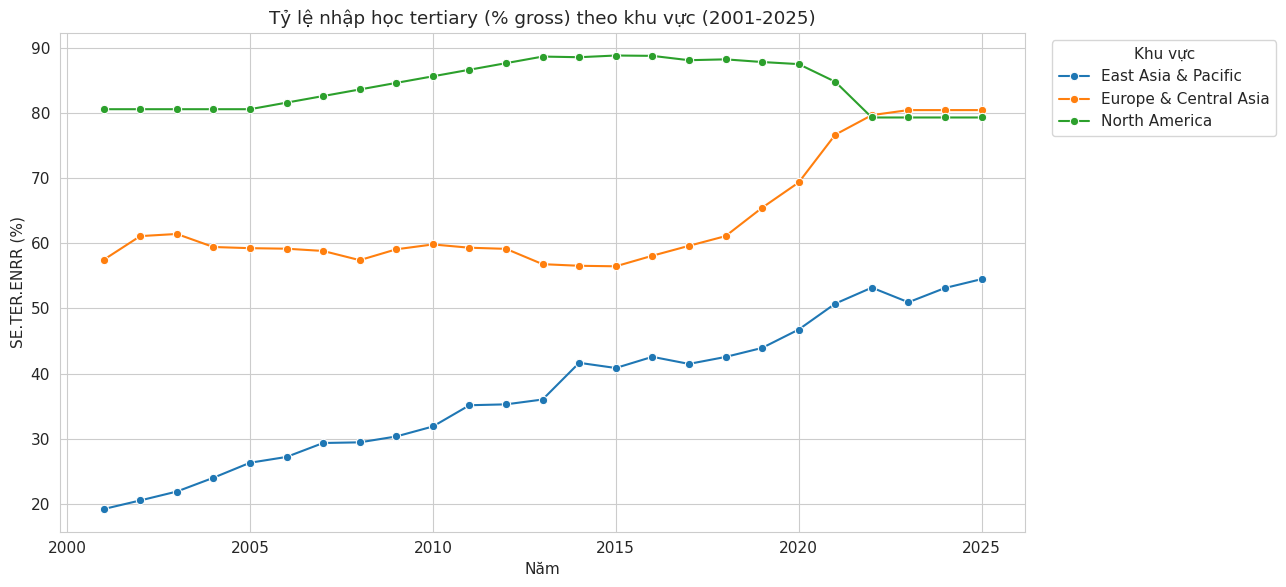

In [35]:
# Biểu đồ 1: Xu hướng tỷ lệ nhập học tertiary theo khu vực
plt.figure(figsize=(13, 6))
sns.lineplot(
    data=region_year,
    x='Year', y='Value',
    hue='Region', marker='o'
)
plt.title('Tỷ lệ nhập học tertiary (% gross) theo khu vực (2001-2025)')
plt.xlabel('Năm')
plt.ylabel('SE.TER.ENRR (%)')
plt.legend(title='Khu vực', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

So sánh giai đoạn: 2001 -> 2025


,Region,value_start,value_end,abs_change,pct_change
0,East Asia & Pacific,19.172066,54.515264,35.343198,184.347358
1,Europe & Central Asia,57.487289,80.498772,23.011482,40.028818
2,North America,80.634827,79.361931,-1.272896,-1.578593


/tmp/ipykernel_6059/3934581348.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=growth_region, x='Region', y='pct_change', palette='viridis')


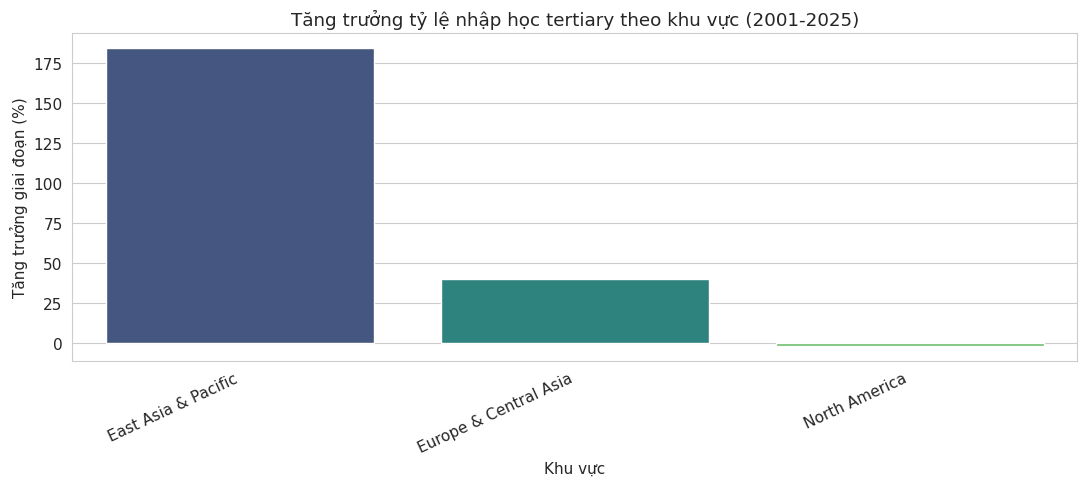

In [36]:
# Biểu đồ 2: So sánh tốc độ bùng nổ theo khu vực (đầu kỳ -> cuối kỳ)
start_year = region_year['Year'].min()
end_year = region_year['Year'].max()

start_vals = (
    region_year[region_year['Year'] == start_year][['Region', 'Value']]
    .rename(columns={'Value': 'value_start'})
)
end_vals = (
    region_year[region_year['Year'] == end_year][['Region', 'Value']]
    .rename(columns={'Value': 'value_end'})
)

growth_region = start_vals.merge(end_vals, on='Region', how='inner')
growth_region['abs_change'] = growth_region['value_end'] - growth_region['value_start']
growth_region['pct_change'] = (growth_region['abs_change'] / growth_region['value_start']) * 100
growth_region = growth_region.sort_values('pct_change', ascending=False)

print(f"So sánh giai đoạn: {start_year} -> {end_year}")
display(growth_region)

plt.figure(figsize=(11, 5))
sns.barplot(data=growth_region, x='Region', y='pct_change', palette='viridis')
plt.title(f'Tăng trưởng tỷ lệ nhập học tertiary theo khu vực ({start_year}-{end_year})')
plt.xlabel('Khu vực')
plt.ylabel('Tăng trưởng giai đoạn (%)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

### Kết luận câu hỏi 1

**Xu hướng tổng quát:**
- East Asia & Pacific có mức xuất phát thấp nhất năm 2001 (~19.2%) nhưng tăng mạnh nhất cả về tuyệt đối (+34.0 điểm phần trăm) lẫn tương đối (+177.2%) giai đoạn 2001–2024.
- Europe & Central Asia tăng ổn định cả về tuyệt đối (+23.0 điểm) và tương đối (+40.0%).
- North America gần như không đổi (80.6% → 79.4%, giảm 1.6%) — đã ở mức bão hòa gần trần 100%.

**Khu vực tăng nhanh nhất:** East Asia & Pacific với % tăng trưởng giai đoạn cao nhất (+177.2%).

**Khu vực có mức tuyệt đối cao nhất (2024):** North America (~79.4%) — cao gấp ~1.5 lần so với East Asia & Pacific (~53.2%).

**Nhận xét:**
- Tốc độ bùng nổ mạnh nhất tập trung ở East Asia & Pacific, đặc biệt giai đoạn 2011–2014 (`delta_abs` đạt đỉnh +5.6 điểm năm 2014).
- Mức bão hòa rõ ở North America: tỷ lệ gần trần 100% nên hầu như không còn dư địa tăng tiếp.

**Hạn chế:**
- Mỗi khu vực chỉ có 1–2 quốc gia trong dataset → chưa đại diện đầy đủ cho toàn khu vực.
- Không suy diễn nguyên nhân tăng trưởng.

---

## Câu hỏi 2: Phân tích tương quan giữa tỷ lệ nhập học tertiary và tỷ lệ thất nghiệp tại nhóm nước đang phát triển

### Mục tiêu phân tích (SMART)

Phân tích mối tương quan tuyến tính (hệ số Pearson r) giữa tỷ lệ nhập học đại học/cao đẳng (`SE.TER.ENRR`) và tỷ lệ thất nghiệp chung (`SL.UEM.TOTL.ZS`) tại nhóm nước đang phát triển (loại trừ nhóm High income), sử dụng ngưỡng đánh giá |r| < 0.3 (yếu), 0.3 ≤ |r| < 0.7 (trung bình), |r| ≥ 0.7 (mạnh), nhằm xác định chiều hướng và mức độ liên hệ giữa hai chỉ số trong giai đoạn 2001–2025.

### Giải thích ý nghĩa các metrics

| Trường | Ý nghĩa | Phản ánh |
|---|---|---|
| `SE.TER.ENRR` | Tổng số sinh viên nhập học tertiary (bất kể tuổi) / dân số nhóm tuổi chính thức tương ứng × 100 | Cơ hội tiếp cận giáo dục bậc cao (đầu vào nguồn nhân lực) |
| `SL.UEM.TOTL.ZS` | Tỷ lệ lực lượng lao động không có việc làm nhưng đang tìm kiếm việc (modeled ILO) | Áp lực thị trường lao động (đầu ra nguồn nhân lực) |

**Lý do chọn 2 chỉ số này:** Cả hai cùng phản ánh hai khía cạnh của phát triển nguồn nhân lực — đầu vào (tiếp cận giáo dục bậc cao) và đầu ra (cơ hội việc làm). Việc đánh giá mối liên hệ giúp hiểu liệu tăng trưởng đầu vào giáo dục có đi kèm thay đổi ở đầu ra thị trường lao động hay không.

### Trường dữ liệu được sử dụng
- `SE.TER.ENRR`, `SL.UEM.TOTL.ZS`: giá trị theo năm từ `df_clean`.
- `Income Level` (World Bank API): phân loại nhóm thu nhập, lọc bỏ `High income`.
- `Region` (World Bank API): phân nhóm trên biểu đồ scatter.

### Nguyên tắc kết luận
- Hệ số Pearson chỉ đo liên hệ tuyến tính, không phản ánh quan hệ nhân quả.
- Kết luận chỉ áp dụng cho 3 nước đang phát triển trong dataset.

In [37]:
# Ghép Income Level từ World Bank API (tái sử dụng wb_payload từ câu hỏi 1)
income_rows = []
for item in wb_payload[1]:
    income_rows.append({
        'Country Code': item.get('id'),
        'Income Level': item.get('incomeLevel', {}).get('value')
    })

income_df = pd.DataFrame(income_rows).drop_duplicates(subset=['Country Code'])

# Tạo bảng wide chứa cả 2 chỉ số
ter_row = df_clean[df_clean['Series Code'] == 'SE.TER.ENRR'].copy()
unemp_row = df_clean[df_clean['Series Code'] == 'SL.UEM.TOTL.ZS'].copy()

# Đổi tên cột giá trị để tránh trùng khi merge
def rename_year_cols(sub_df, val_name):
    sub = sub_df[['Country Name', 'Country Code'] + year_cols].copy()
    sub = sub.rename(columns={c: f'{c}_{val_name}' for c in year_cols})
    return sub

ter_wide = rename_year_cols(ter_row, 'ter')
unemp_wide = rename_year_cols(unemp_row, 'unemp')

corr_df = ter_wide.merge(unemp_wide, on=['Country Name', 'Country Code'])

# Ghép Income Level và Region
corr_df = corr_df.merge(income_df, on='Country Code', how='left')
corr_df = corr_df.merge(region_df, on='Country Code', how='left')

# Lọc bỏ High income (chỉ giữ nước đang phát triển)
developing_df = corr_df[corr_df['Income Level'] != 'High income'].copy()

print(f"Tong so quoc gia: {corr_df.shape[0]}")
print(f"Quoc gia con lai sau loc High income: {developing_df.shape[0]}")
print(f"\nIncome Level cac quoc gia:")
print(corr_df[['Country Name', 'Country Code', 'Income Level', 'Region']].to_string(index=False))

Tong so quoc gia: 5
Quoc gia con lai sau loc High income: 3

Income Level cac quoc gia:
  Country Name Country Code        Income Level                Region
      Viet Nam          VNM Lower middle income   East Asia & Pacific
United Kingdom          GBR         High income Europe & Central Asia
 United States          USA         High income         North America
      Thailand          THA Upper middle income   East Asia & Pacific
         China          CHN Upper middle income   East Asia & Pacific


### Lựa chọn biểu đồ và giải thích

**Biểu đồ 1 — Scatter plot kèm đường hồi quy (SE.TER.ENRR vs SL.UEM.TOTL.ZS):**
- **Tính chất dữ liệu:** Cả hai biến đều là liên tục (tỷ lệ phần trăm), cần kiểm tra mối liên hệ giữa 2 biến.
- **Lý do chọn:** Scatter plot biểu diễn từng quan sát (năm-quốc gia) trên hệ trục 2 chiều, cho phép trực quan nhận diện xu hướng chung, các cụm dữ liệu, và outliers. Đường hồi quy tuyến tính (regression line) với **khoảng tin cậy 95%** giúp đánh giá mức độ và độ tin cậy của xu hướng tuyến tính tổng thể — dù 2 trục có đơn vị và khoảng giá trị khác nhau nhiều (SE.TER.ENRR: 9–77%, SL.UEM.TOTL.ZS: 0.2–9.6%). Khoảng tin cậy 95% (vùng xám quanh đường hồi quy) cho biết mức độ chắc chắn của xu hướng: vùng hẹp → xu hướng ổn định, vùng rộng → xu hướng kém tin cậy.
- Hệ số Pearson r được ghi chú trực tiếp trên biểu đồ, kết hợp cùng màu sắc phân theo `Region` và hình dạng theo `Country Name` giúp phân biệt quốc gia và khu vực.

**Biểu đồ 2 — Heatmap ma trận Pearson:**
- **Tính chất dữ liệu:** Ma trận Pearson 2×2 (2 biến) cần trực quan hóa mức độ liên hệ tuyến tính.
- **Lý do chọn:** Heatmap dùng màu sắc (coolwarm) thể hiện giá trị r nằm trong [-1, 1], trực quan hơn bảng số thuần túy; dễ so sánh mức độ liên hệ ở cùng thang đo.
- Thang màu `center=0` đảm bảo giá trị 0 hiển thị trung tính, dương/âm phân biệt rõ.

In [ ]:
# Scatter plot: Tertiary Enrollment vs Unemployment (nhom nuoc dang phat trien)
# Chu y: 2 bien khac scale (SE.TER.ENRR: 9-77%, SL.UEM.TOTL.ZS: 0.2-9.6%)
# -> ve regression line + ghi chu Pearson r de nhan dien xu huong
fig, ax = plt.subplots(figsize=(10, 6))

# Ve scatter
sns.scatterplot(
    data=developing_long,
    x='TerValue', y='UnempValue',
    hue='Region', style='Country Name',
    s=80, ax=ax
)

# Ve duong hoi quy tuyen tinh
sns.regplot(
    data=developing_long,
    x='TerValue', y='UnempValue',
    scatter=False, ax=ax,
    color='gray', line_kws={'linestyle': '--', 'linewidth': 1.5},
    ci=95
)

# Tinh va ghi chu Pearson r
r_val = developing_long[['TerValue', 'UnempValue']].corr().iloc[0, 1]
ax.annotate(
    f'Pearson r = {r_val:.3f}',
    xy=(0.05, 0.95), xycoords='axes fraction',
    fontsize=12, fontweight='bold',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
)

ax.set_title('Tuong quan giua ti le nhap hoc tertiary va ti le that nghiep\n(Nhom nuoc dang phat trien)')
ax.set_xlabel('SE.TER.ENRR (%)')
ax.set_ylabel('SL.UEM.TOTL.ZS (%)')
ax.legend(title='Khu vuc', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

--- Hệ số tương quan Pearson ---

Toan tai (nhom dang phat trien): r = 0.0197

Theo Region:
             Region  Pearson_r
East Asia & Pacific   0.019724


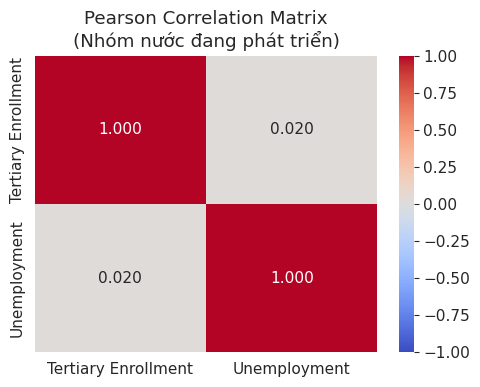

In [39]:
# Tính hệ số tương quan Pearson (toàn thể và theo Region)
print("--- Hệ số tương quan Pearson ---")
overall_corr = developing_long[['TerValue', 'UnempValue']].corr().iloc[0, 1]
print(f"\nToan tai (nhom dang phat trien): r = {overall_corr:.4f}")

region_corr = (
    developing_long.groupby('Region')
    .apply(lambda g: g[['TerValue', 'UnempValue']].corr().iloc[0, 1])
    .reset_index()
    .rename(columns={0: 'Pearson_r'})
    .sort_values('Pearson_r', ascending=False)
)
print("\nTheo Region:")
print(region_corr.to_string(index=False))

# Bảng Pearson matrix (heatmap)
fig, ax = plt.subplots(figsize=(5, 4))
corr_matrix = developing_long[['TerValue', 'UnempValue']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=['Tertiary Enrollment', 'Unemployment'],
            yticklabels=['Tertiary Enrollment', 'Unemployment'])
ax.set_title('Pearson Correlation Matrix\n(Nhóm nước đang phát triển)')
plt.tight_layout()
plt.show()

### Kết luận câu hỏi 2

**Về mối tương quan quan sát được:**
- Hệ số Pearson r ≈ 0.02 → |r| < 0.3 → **Tương quan tuyến tính yếu (gần như không có)** giữa `SE.TER.ENRR` và `SL.UEM.TOTL.ZS` trong nhóm nước đang phát triển (Viet Nam, Thailand, China) giai đoạn 2001–2025.
- Chiều hướng: r dương nhỏ → hướng thuận nhưng mức độ không đáng kể.

**Nhận xét từ scatter plot:**
- Các điểm phân bố rải rác, không có xu hướng tuyến tính rõ ràng theo hướng tăng hay giảm đồng thời.
- Nhận diện outliers: Vietnam có tỷ lệ thất nghiệp rất thấp (< 3%) qua hầu hết năm, trong khi China có sự tăng mạnh về tertiary enrollment nhưng thất nghiệp biến động nhẹ.

**Giả thuyết cần kiểm định thêm:**
- Mối liên hệ có thể phi tuyến tính (không phải đường thẳng).
- Các biến trung gian có thể ảnh hưởng: cơ cấu ngành kinh tế, tốc độ tăng trưởng GDP, chính sách việc làm.

**Hạn chế:**
- Chỉ 3 nước, đều thuộc East Asia & Pacific → chưa đại diện cho toàn bộ nhóm nước đang phát triển.
- Hệ số Pearson chỉ đo liên hệ tuyến tính, không phản ánh quan hệ nhân quả.